# TinyLlama Fine-Tuning on OpenMath Dataset
**Model:** TinyLlama/TinyLlama-1.1B-Chat-v1.0  
**Dataset:** openmath_preprocessed.jsonl (3,000 samples from S3)  
**Method:** QLoRA (4-bit quantization + LoRA adapters)  
**Epochs:** 3

## 1. Install Dependencies

In [14]:
!pip install -q transformers peft trl accelerate bitsandbytes datasets boto3

## 2. Import Libraries

In [ ]:
from datasets import Dataset
import pandas as pd
import torch
import boto3
import os
import json
import random
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from collections import Counter
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    AutoConfig,
    BitsAndBytesConfig,
    TrainingArguments,
    DataCollatorForLanguageModeling
)
from torch.utils.data import DataLoader
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer

# Fix random seed for reproducibility
random.seed(42)
np.random.seed(42)

# ==============================
# 1) AWS Credentials  ← PUT REAL VALUES HERE
# ==============================


print("All libraries imported successfully.")
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

All libraries imported successfully.
CUDA available: True
GPU: NVIDIA RTX 2000 Ada Generation


In [ ]:
import boto3

sts = boto3.client(
    "sts",
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=AWS_DEFAULT_REGION,
)

sts.get_caller_identity()

In [16]:
print("AWS_ACCESS_KEY_ID:", AWS_ACCESS_KEY_ID[:6] + "..." if AWS_ACCESS_KEY_ID else "MISSING")
print("AWS_SECRET_ACCESS_KEY loaded:", bool(AWS_SECRET_ACCESS_KEY))
print("AWS_DEFAULT_REGION:", AWS_DEFAULT_REGION)
print("Secret length:", len(AWS_SECRET_ACCESS_KEY) if AWS_SECRET_ACCESS_KEY else 0)

AWS_ACCESS_KEY_ID: AKIA6O...
AWS_SECRET_ACCESS_KEY loaded: True
AWS_DEFAULT_REGION: us-east-1
Secret length: 40


## 3. Load Preprocessed Dataset from S3

In [18]:
import boto3
import json
import pandas as pd

# ==============================
# 2) Config
# ==============================
S3_BUCKET   = "cloud-project-time4"
S3_DATA_KEY = "data/openmath_preprocessed.jsonl"
NUM_SAMPLES = 20000

# Create S3 client using credentials from Cell 1
s3 = boto3.client(
    "s3",
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=AWS_DEFAULT_REGION,
)

# ==============================
# 3) LIST FILES
# ==============================
print("\nAll files in bucket:\n")

response = s3.list_objects_v2(Bucket=S3_BUCKET)

all_keys = []
for obj in response.get("Contents", []):
    key = obj["Key"]
    all_keys.append(key)
    print(key)

# ==============================
# 4) Auto-detect correct file
# ==============================
print("\nSearching for your file...\n")

correct_key = None
for key in all_keys:
    if "openmath" in key.lower():
        correct_key = key
        break

if correct_key:
    print(f"Found file: {correct_key}")
    S3_DATA_KEY = correct_key
else:
    raise Exception("File not found in bucket — you need to upload it")

# ==============================
# 5) Load file safely
# ==============================
print(f"\nLoading from s3://{S3_BUCKET}/{S3_DATA_KEY} ...")

response = s3.get_object(Bucket=S3_BUCKET, Key=S3_DATA_KEY)
lines = response["Body"].read().decode("utf-8").splitlines()

records = [json.loads(line) for line in lines[:NUM_SAMPLES]]
df = pd.DataFrame(records)

print(f"\nLoaded {len(df)} records")
print("Columns:", df.columns.tolist())

df.head(3)


All files in bucket:

dataset/final/train/_SUCCESS
dataset/final/train/part-00000-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-c000.snappy.parquet
dataset/final/train/part-00001-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-c000.snappy.parquet
dataset/final/train/part-00002-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-c000.snappy.parquet
dataset/final/train/part-00003-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-c000.snappy.parquet
dataset/final/train/part-00004-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-c000.snappy.parquet
dataset/final/train/part-00005-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-c000.snappy.parquet
dataset/final/train/part-00006-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-c000.snappy.parquet
dataset/final/train/part-00007-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-c000.snappy.parquet
dataset/final/train/part-00008-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-c000.snappy.parquet
dataset/final/train/part-00009-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-c000.snappy.parquet
dataset/final/train/part-00010-527f6870-93bf-40a1-be1b-cfe4fc5aacc2-

,problem,generated_solution,expected_answer,problem_source
0,"Problem:\nIn a cryptographic system, a message...","To find the original plaintext message M, we n...",97,augmented_math
1,Simplify the expression $\left( \frac{2x^2}{3y...,Apply the properties of exponents:\n\[ \left( ...,\frac{243y^7}{8x^4},augmented_math
2,"A certain five-digit integer $A\,B\,C\,D\,E$, ...",## Step 1: Understand the conditions given for...,8,augmented_math


## 4. Exploratory Data Analysis (EDA)

In [19]:
print("=" * 55)
print("           DATASET OVERVIEW")
print("=" * 55)

print(f"  Total records  : {len(df)}")
print(f"  Columns        : {df.columns.tolist()}")
print(f"  Missing values :\n{df.isnull().sum().to_string()}")
print()

df["text"] = (
    "<|user|>\n" + df["problem"] +
    "\n<|assistant|>\n" + df["generated_solution"]
)

df["text_chars"] = df["text"].astype(str).apply(len)
df["text_words"] = df["text"].astype(str).apply(lambda x: len(x.split()))

has_assistant = df["text"].str.contains("<|assistant|>").sum()
print(f"  Samples with <|assistant|> tag : {has_assistant} / {len(df)}")
print()

print("  Text length (characters):")
print(df["text_chars"].describe().round(1).to_string())
print()

print("  Text length (words):")
print(df["text_words"].describe().round(1).to_string())

           DATASET OVERVIEW
  Total records  : 20000
  Columns        : ['problem', 'generated_solution', 'expected_answer', 'problem_source']
  Missing values :
problem               0
generated_solution    0
expected_answer       0
problem_source        0

  Samples with <|assistant|> tag : 20000 / 20000

  Text length (characters):
count    20000.0
mean      1370.6
std        770.2
min        252.0
25%        814.0
50%       1192.0
75%       1748.0
max      10791.0

  Text length (words):
count    20000.0
mean       253.8
std        138.8
min         25.0
25%        151.0
50%        223.0
75%        324.0
max       2032.0


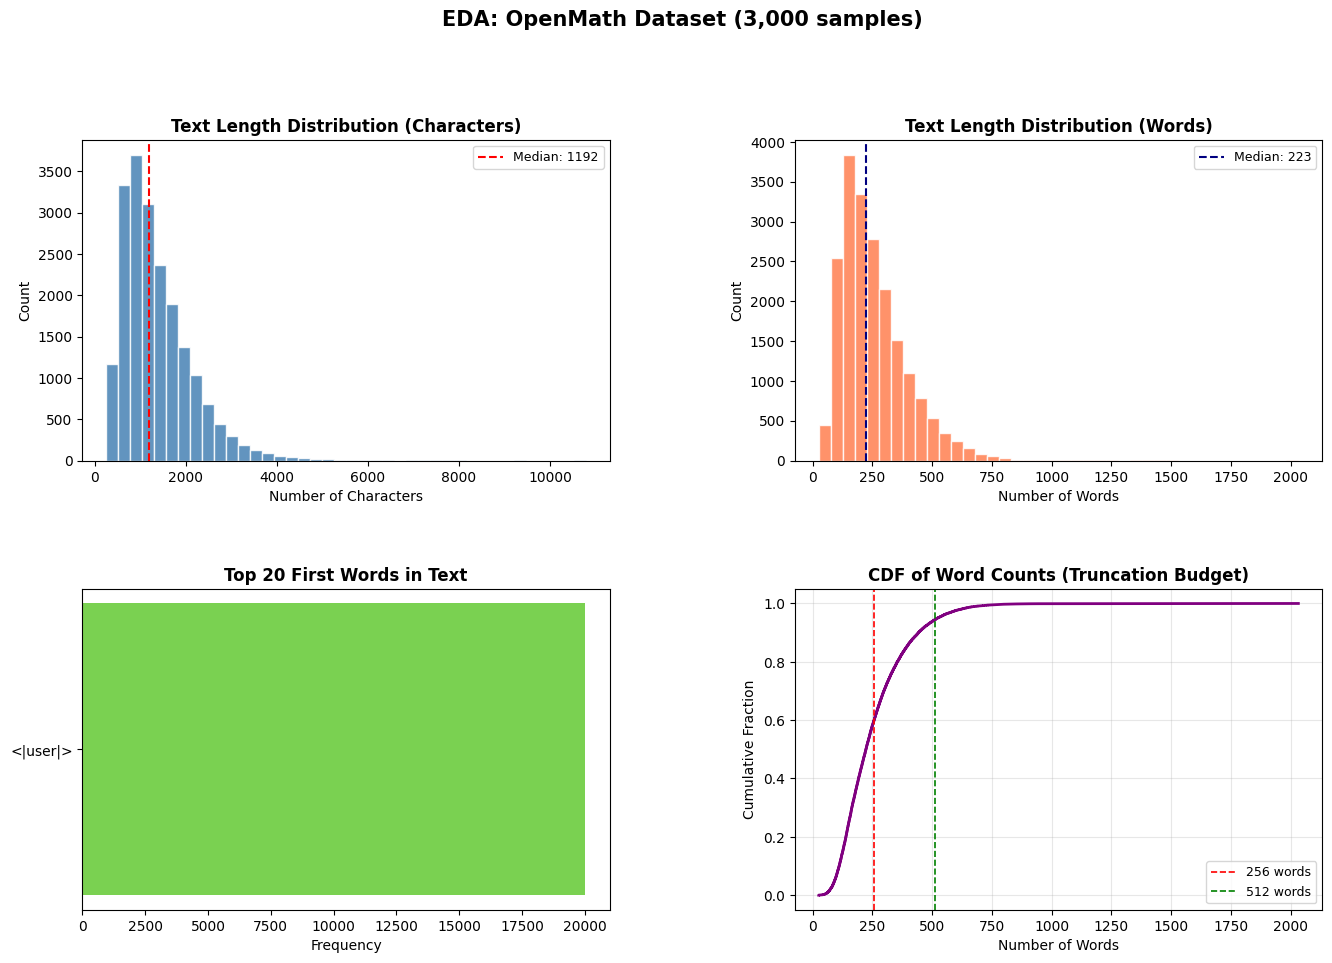

EDA plots saved to eda_full_analysis.png


In [20]:
# ── EDA visualizations: 4 charts in a 2×2 grid ───────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle("EDA: OpenMath Dataset (3,000 samples)", fontsize=15, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Plot 1: Character length distribution ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df["text_chars"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax1.axvline(df["text_chars"].median(), color="red", linestyle="--", linewidth=1.5,
            label=f"Median: {df['text_chars'].median():.0f}")
ax1.set_title("Text Length Distribution (Characters)", fontweight="bold")
ax1.set_xlabel("Number of Characters")
ax1.set_ylabel("Count")
ax1.legend(fontsize=9)

# ── Plot 2: Word count distribution ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(df["text_words"], bins=40, color="coral", edgecolor="white", alpha=0.85)
ax2.axvline(df["text_words"].median(), color="navy", linestyle="--", linewidth=1.5,
            label=f"Median: {df['text_words'].median():.0f}")
ax2.set_title("Text Length Distribution (Words)", fontweight="bold")
ax2.set_xlabel("Number of Words")
ax2.set_ylabel("Count")
ax2.legend(fontsize=9)

# ── Plot 3: Top 20 first words ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
first_words   = df["text"].astype(str).apply(lambda x: x.split()[0].lower() if x.split() else "")
top_words     = Counter(first_words).most_common(20)
words, counts = zip(*top_words)
colors        = plt.cm.viridis_r(np.linspace(0.2, 0.85, len(words)))
ax3.barh(words[::-1], counts[::-1], color=colors)
ax3.set_xlabel("Frequency")
ax3.set_title("Top 20 First Words in Text", fontweight="bold")

# ── Plot 4: Cumulative distribution of word counts (to see token budget) ──────
ax4 = fig.add_subplot(gs[1, 1])
sorted_words = np.sort(df["text_words"])
cdf          = np.arange(1, len(sorted_words) + 1) / len(sorted_words)
ax4.plot(sorted_words, cdf, color="purple", linewidth=2)
ax4.axvline(256, color="red",   linestyle="--", linewidth=1.2, label="256 words")
ax4.axvline(512, color="green", linestyle="--", linewidth=1.2, label="512 words")
ax4.set_title("CDF of Word Counts (Truncation Budget)", fontweight="bold")
ax4.set_xlabel("Number of Words")
ax4.set_ylabel("Cumulative Fraction")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.savefig("eda_full_analysis.png", dpi=130, bbox_inches="tight")
plt.show()
print("EDA plots saved to eda_full_analysis.png")

In [21]:
# Print 3 random samples to visually verify the data format
print("\n" + "=" * 60)
print("          RANDOM SAMPLES FROM DATASET")
print("=" * 60)
for i, idx in enumerate(random.sample(range(len(df)), 3)):
    print(f"\n--- Sample {i+1} (index {idx}) ---")
    print(df.iloc[idx]["text"][:400])
    print()


          RANDOM SAMPLES FROM DATASET

--- Sample 1 (index 3648) ---
<|user|>
Find the smallest positive value of $x$ for which $\cos 3x = \sin 2x$.
<|assistant|>
The equation we are given is
\[ \cos 3x = \sin 2x \]

Use the identity $\sin 2x = \cos \left( \frac{\pi}{2} - 2x \right)$ to rewrite the equation as:
\[ \cos 3x = \cos \left( \frac{\pi}{2} - 2x \right) \]

Since the cosine function is periodic with period $2\pi$, and we want the smallest positive solution


--- Sample 2 (index 819) ---
<|user|>
Evaluate
\[\begin{vmatrix} \cosh \alpha \cosh \beta & \cosh \alpha \sinh \beta & -\sinh \alpha \\ -\sinh \beta & \cosh \beta & 0 \\ \sinh \alpha \cosh \beta & \sinh \alpha \sinh \beta & \cosh \alpha \end{vmatrix}.\]
<|assistant|>
To evaluate the given determinant, we can use properties of determinants and hyperbolic functions.

First, recall the definitions of hyperbolic functions:
\[ \co


--- Sample 3 (index 9012) ---
<|user|>
Given $f(x) = x^2 + 2x + 1$, what is the value of $f(f(x

## 5. Split Dataset

In [ ]:
# Convert DataFrame to a HuggingFace Dataset object 
dataset = Dataset.from_pandas(df[["text"]])

# Step 1: 85% train, 15% temporary pool
split_tv = dataset.train_test_split(test_size=0.15, seed=42)

# Step 2: Split the 15% pool equally into validation and test sets
split_vt = split_tv["test"].train_test_split(test_size=0.5, seed=42)

train_data = split_tv["train"]   # 85% of 3,000 ≈ 2,550 samples
val_data   = split_vt["train"]   # 7.5% of 3,000 ≈ 225  samples
test_data  = split_vt["test"]    # 7.5% of 3,000 ≈ 225  samples

print(f"Split sizes  →  Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print(f"Total        →  {len(train_data) + len(val_data) + len(test_data)}")
print("\nSample training example (first 300 chars):")
print(train_data[0]["text"][:300])

Split sizes  →  Train: 17000 | Val: 1500 | Test: 1500
Total        →  20000

Sample training example (first 300 chars):
<|user|>
In triangle $ABC$, $AB = AC$ and the measure of $\angle A$ is 60 degrees. A square is inscribed in the triangle such that its sides are parallel to the sides of the triangle and one of its vertices is at vertex $A$. If the side length of the square is 6 units, what is the perimeter of trian


## 6. Load Model (TinyLlama with 4-bit QLoRA)

In [23]:
# Base model identifier from HuggingFace Hub
MODEL_ID = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

In [ ]:
# Load tokenizer and assign pad token to eos token 
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
print(f"Tokenizer loaded. Vocab size: {tokenizer.vocab_size:,}")

Tokenizer loaded. Vocab size: 32,000


In [25]:
# Load model config and set pad token id to match tokenizer
config = AutoConfig.from_pretrained(MODEL_ID)
config.pad_token_id = config.eos_token_id

# Load model with 4-bit NF4 quantization to reduce GPU VRAM usage (~2–3 GB instead of ~4–5 GB)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    config=config,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,   # use bfloat16 for stable training
        bnb_4bit_use_double_quant=True,           # double quantization to save extra memory
        bnb_4bit_quant_type="nf4"                 # normal float 4 (best quality for LLMs)
    ),
    device_map="auto"                             # automatically distribute layers across available GPUs
)
print("Model loaded successfully!")

# Count and display trainable parameters before applying LoRA
total_params = sum(p.numel() for p in model.parameters())
print(f"Total model parameters: {total_params:,}")

Model loaded successfully!
Total model parameters: 615,606,272


## 7. Fine-Tuning with QLoRA (3 Epochs)

In [26]:
# Prepare model for k-bit (4-bit) LoRA training
# This casts layer norms to float32 and enables gradient checkpointing
model = prepare_model_for_kbit_training(model)

# LoRA configuration: inject trainable low-rank matrices into attention projections
lora_config = LoraConfig(
    r=16,                                               # rank of the LoRA update matrices
    lora_alpha=32,                                      # scaling factor (alpha/r = 2 is standard)
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],  # inject into all attention projections
    lora_dropout=0.05,                                  # dropout on LoRA layers to reduce overfitting
    bias="none",                                        # do not train bias terms
    task_type="CAUSAL_LM"                               # task type for causal language modeling
)

# Training arguments
training_args = TrainingArguments(
    output_dir="./llama-math",
    num_train_epochs=1,                 # train for 3 full epochs over the training set
    per_device_train_batch_size=2,      # small batch size to fit in GPU memory
    gradient_accumulation_steps=8,      # effective batch size = 2 * 8 = 16
    learning_rate=2e-4,                 # learning rate for AdamW optimizer
    bf16=True,                          # use bfloat16 precision for faster training
    fp16=False,                         # disable fp16 (conflicts with bf16)
    logging_steps=50,                   # log training loss every 50 steps
    eval_strategy="steps",             # run evaluation at fixed step intervals
    eval_steps=300,                     # evaluate every 300 steps
    save_steps=300,                     # save checkpoint every 300 steps
    load_best_model_at_end=True,        # restore best checkpoint after training
    metric_for_best_model="eval_loss",  # use validation loss to select best model
    report_to="none"                    # disable W&B / TensorBoard logging
)

# Initialize the SFT (Supervised Fine-Tuning) trainer
trainer = SFTTrainer(
    model=model,
    train_dataset=train_data,
    eval_dataset=val_data,
    peft_config=lora_config,
    args=training_args,
)

# Start training
print("Starting fine-tuning ...")
train_result = trainer.train()
print("Training complete!")
print(f"Total training time : {train_result.metrics.get('train_runtime', 0):.1f} seconds")
print(f"Final training loss : {train_result.metrics.get('train_loss', 0):.4f}")

Adding EOS to train dataset:   0%|          | 0/17000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/17000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2410 > 2048). Running this sequence through the model will result in indexing errors


Truncating train dataset:   0%|          | 0/17000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/1500 [00:00<?, ? examples/s]

...

Starting fine-tuning ...


/opt/venv/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
300,0.738600,0.733965,0.763151,2401306.000000,0.790266
600,0.710400,0.709154,0.734829,4873689.000000,0.795903
900,0.702600,0.697610,0.714056,7311308.000000,0.798740


/opt/venv/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/opt/venv/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/opt/venv/lib/python

Training complete!
Total training time : 8323.9 seconds
Final training loss : 0.7280


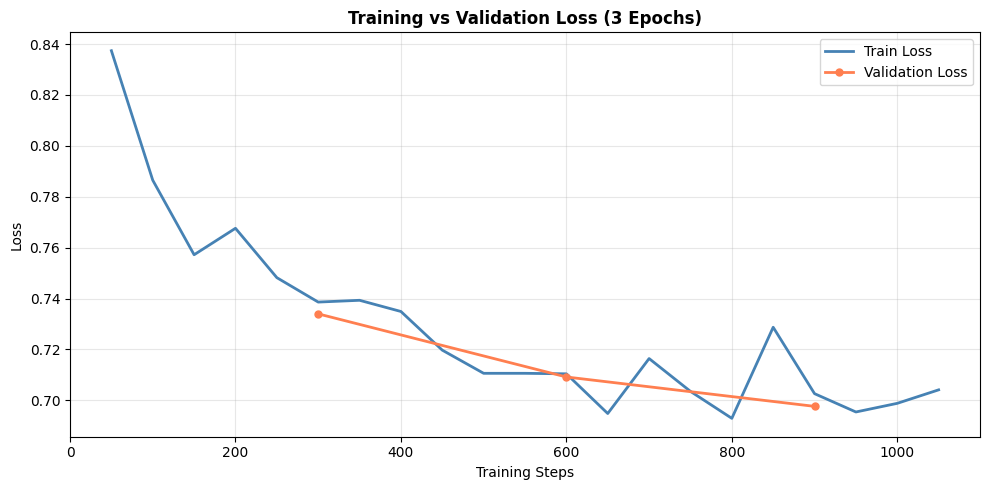

Loss curve saved to training_loss_curve.png


In [27]:
# ── Plot training and validation loss curves from the trainer log history ─────
log_history = trainer.state.log_history

# Extract training loss entries
train_steps  = [entry["step"] for entry in log_history if "loss" in entry]
train_losses = [entry["loss"] for entry in log_history if "loss" in entry]

# Extract validation loss entries
eval_steps  = [entry["step"]      for entry in log_history if "eval_loss" in entry]
eval_losses = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label="Train Loss",      color="steelblue", linewidth=2)
plt.plot(eval_steps,  eval_losses,  label="Validation Loss", color="coral",
         linewidth=2, marker="o", markersize=5)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (3 Epochs)", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss_curve.png", dpi=130)
plt.show()
print("Loss curve saved to training_loss_curve.png")

## 8. Evaluation on Test Set

In [ ]:
# ── Compute test loss and perplexity 
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=512,
        padding="max_length"
    )

tokenized_test = test_data.map(tokenize_fn, batched=True, remove_columns=["text"])
tokenized_test.set_format("torch")

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
test_loader = DataLoader(tokenized_test, batch_size=4, collate_fn=collator)

# Compute average cross-entropy loss over the full test set
model.eval()
total_loss, total_steps = 0.0, 0

with torch.no_grad():
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        for batch in test_loader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            output = model(**batch)
            total_loss += output.loss.item()
            total_steps += 1

avg_loss = total_loss / total_steps
perplexity = math.exp(avg_loss)

print("=" * 48)
print("        TEST SET EVALUATION RESULTS")
print("=" * 48)
print(f"  Test Samples  : {len(test_data)}")
print(f"  Test Loss     : {avg_loss:.4f}")
print(f"  Perplexity    : {perplexity:.2f}")
print("=" * 48)
print("  Interpretation: lower perplexity = better model.")
print(f"  A perplexity of {perplexity:.1f} means the model is")
print(f"  as uncertain as choosing uniformly from ~{perplexity:.0f} tokens.")
print("=" * 48)

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

        TEST SET EVALUATION RESULTS
  Test Samples  : 1500
  Test Loss     : 0.7097
  Perplexity    : 2.03
  Interpretation: lower perplexity = better model.
  A perplexity of 2.0 means the model is
  as uncertain as choosing uniformly from ~2 tokens.


In [31]:
# ── Generate predictions for 5 random test examples ───────────────────────────
print("=" * 65)
print("          SAMPLE PREDICTIONS ON TEST SET")
print("=" * 65)

model.eval()
sample_indices = random.sample(range(len(test_data)), 5)

for i, idx in enumerate(sample_indices):
    raw_text = test_data[idx]["text"]

    # Split at assistant tag
    parts = raw_text.split("<|assistant|>")
    prompt = parts[0] + "<|assistant|>\n"
    reference = parts[-1].replace("</s>", "").strip() if len(parts) > 1 else "N/A"

    # Tokenize prompt
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Generate with correct dtype
    with torch.no_grad():
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            outputs = model.generate(
                **inputs,
                max_new_tokens=150,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id
            )

    # Decode only generated continuation
    generated_tokens = outputs[0][inputs.input_ids.shape[-1]:]
    generated_answer = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()

    print(f"\n{'─' * 65}")
    print(f"  Test Sample {i+1} / 5")
    print(f"{'─' * 65}")
    print("  PROMPT    :", prompt.replace("\n", " ")[:220])
    print("  REFERENCE :", reference[:220])
    print("  GENERATED :", generated_answer[:220])

print(f"\n{'=' * 65}")
print("  Prediction complete.")
print(f"{'=' * 65}")

          SAMPLE PREDICTIONS ON TEST SET

─────────────────────────────────────────────────────────────────
  Test Sample 1 / 5
─────────────────────────────────────────────────────────────────
  PROMPT    : <|user|> In triangle $ABC$, the bisectors of angles $A$, $B$, and $C$ intersect at the incenter $I$. If $\angle ABC = 110^\circ$ and $\angle ACB = 120^\circ$, then find the measure of $\angle BIC$, in degrees. <|assistan
  REFERENCE : Given that $\angle ABC = 110^\circ$ and $\angle ACB = 120^\circ$, we know that $\angle BAC = 180^\circ - 110^\circ - 120^\circ = 130^\circ - 110^\circ = 20^\circ$.

Let's find the measure of $\angle BIC$ step-by-step:

1
  GENERATED : Let's denote the incenter as $I$.

Since $\angle ABC = 110^\circ$ and $\angle ACB = 120^\circ$, we know that $I$ is a right triangle with $AB = AC = 1$.

Since $I$ is the incenter, we can use the fact that the incenter i

─────────────────────────────────────────────────────────────────
  Test Sample 2 / 5
──────────────

## 9. Save Model to S3

In [32]:
LOCAL_MODEL_DIR = "./final-model"
S3_MODEL_PREFIX = "models/llama-finetuned-v4"   # new folder name to avoid overwriting previous runs

# Save LoRA-adapted model weights and tokenizer files to local disk first
print(f"Saving model locally to {LOCAL_MODEL_DIR} ...")
trainer.save_model(LOCAL_MODEL_DIR)
tokenizer.save_pretrained(LOCAL_MODEL_DIR)
print("Local save complete.")

# Upload every file in the saved directory to S3
print(f"\nUploading to s3://{S3_BUCKET}/{S3_MODEL_PREFIX}/ ...")
uploaded_count = 0
for filename in os.listdir(LOCAL_MODEL_DIR):
    local_path = os.path.join(LOCAL_MODEL_DIR, filename)
    if os.path.isfile(local_path):                   # skip any subdirectories
        s3_key = f"{S3_MODEL_PREFIX}/{filename}"
        s3.upload_file(local_path, S3_BUCKET, s3_key)
        print(f"  Uploaded: {filename}")
        uploaded_count += 1

print(f"\nDone! {uploaded_count} file(s) saved to s3://{S3_BUCKET}/{S3_MODEL_PREFIX}/")

Saving model locally to ./final-model ...
Local save complete.

Uploading to s3://cloud-project-time4/models/llama-finetuned-v4/ ...
  Uploaded: tokenizer_config.json
  Uploaded: adapter_model.safetensors
  Uploaded: tokenizer.json
  Uploaded: adapter_config.json
  Uploaded: README.md
  Uploaded: training_args.bin
  Uploaded: special_tokens_map.json
  Uploaded: tokenizer.model
  Uploaded: chat_template.jinja

Done! 9 file(s) saved to s3://cloud-project-time4/models/llama-finetuned-v4/
